# 01 — Exploratory Data Analysis (CORD-v2)

This notebook explores the CORD-v2 dataset to understand:
- Image dimensions and aspect ratios
- Number of items per receipt
- Field completeness (which fields are present/missing)
- Sample visualization

In [1]:
import json
import os
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR = Path("../data/raw")

## 1. Dataset Overview

In [2]:
splits = {}
for split in ["train", "validation", "test"]:
    img_dir = DATA_DIR / split / "images"
    ann_dir = DATA_DIR / split / "annotations"
    n_images = len(list(img_dir.glob("*.png")))
    n_annotations = len(list(ann_dir.glob("*.json")))
    splits[split] = {"images": n_images, "annotations": n_annotations}

print("Dataset splits:")
for split, counts in splits.items():
    print(f"  {split}: {counts['images']} images, {counts['annotations']} annotations")
print(f"  Total: {sum(c['images'] for c in splits.values())} images")

Dataset splits:
  train: 800 images, 800 annotations
  validation: 100 images, 100 annotations
  test: 100 images, 100 annotations
  Total: 1000 images


## 2. Image Dimensions Analysis

In [3]:
widths, heights = [], []

for split in ["train", "validation", "test"]:
    img_dir = DATA_DIR / split / "images"
    for img_path in sorted(img_dir.glob("*.png")):
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}, std: {np.std(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}, std: {np.std(heights):.0f}")

Width  — min: 204, max: 3024, mean: 999, std: 546
Height — min: 336, max: 4224, mean: 1575, std: 995


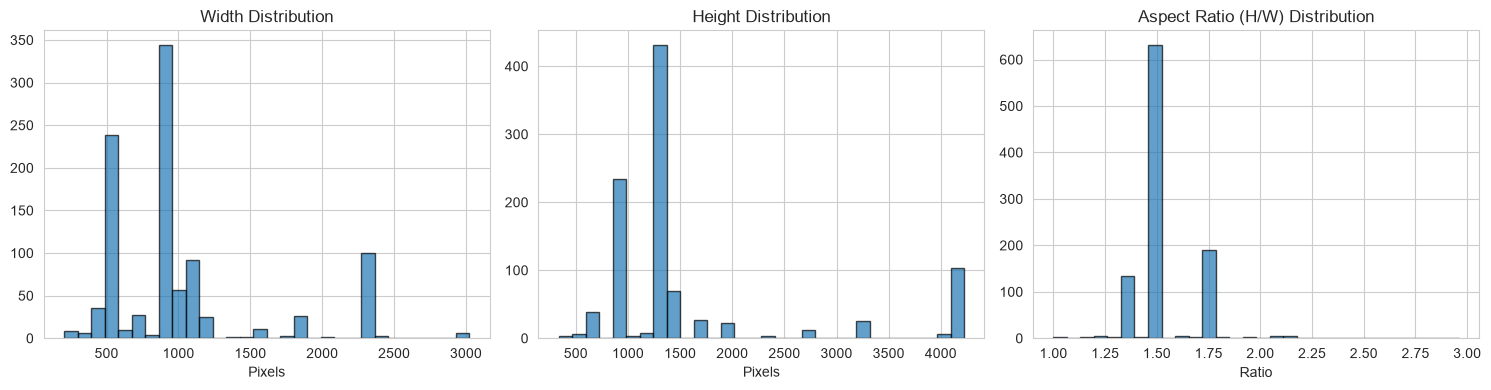

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(widths, bins=30, edgecolor="black", alpha=0.7)
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Pixels")

axes[1].hist(heights, bins=30, edgecolor="black", alpha=0.7)
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Pixels")

aspect_ratios = [h / w for w, h in zip(widths, heights)]
axes[2].hist(aspect_ratios, bins=30, edgecolor="black", alpha=0.7)
axes[2].set_title("Aspect Ratio (H/W) Distribution")
axes[2].set_xlabel("Ratio")

plt.tight_layout()
plt.savefig("../results/figures/image_dimensions.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Annotation Field Completeness

In [5]:
# Analyze field presence across all annotations
field_presence = {
    "menu": 0, "sub_total": 0, "total": 0,
    "menu.nm": 0, "menu.cnt": 0, "menu.price": 0, "menu.unitprice": 0,
    "sub_total.subtotal_price": 0, "sub_total.tax_price": 0, "sub_total.service_price": 0,
    "total.total_price": 0, "total.cashprice": 0, "total.changeprice": 0,
}

n_total = 0
n_items_total = 0
items_per_receipt = []

for split in ["train", "validation", "test"]:
    ann_dir = DATA_DIR / split / "annotations"
    for ann_path in sorted(ann_dir.glob("*.json")):
        with open(ann_path) as f:
            data = json.load(f)
        gt = data.get("gt_parse", {})
        n_total += 1

        # Top-level fields
        if "menu" in gt:
            field_presence["menu"] += 1
            menu = gt["menu"]
            if isinstance(menu, dict):
                menu = [menu]
            items_per_receipt.append(len(menu))
            for item in menu:
                if isinstance(item, dict):
                    n_items_total += 1
                    if "nm" in item: field_presence["menu.nm"] += 1
                    if "cnt" in item: field_presence["menu.cnt"] += 1
                    if "price" in item: field_presence["menu.price"] += 1
                    if "unitprice" in item: field_presence["menu.unitprice"] += 1
        else:
            items_per_receipt.append(0)

        if "sub_total" in gt:
            field_presence["sub_total"] += 1
            sub = gt["sub_total"]
            if isinstance(sub, dict):
                if "subtotal_price" in sub: field_presence["sub_total.subtotal_price"] += 1
                if "tax_price" in sub: field_presence["sub_total.tax_price"] += 1
                if "service_price" in sub: field_presence["sub_total.service_price"] += 1

        if "total" in gt:
            field_presence["total"] += 1
            tot = gt["total"]
            if isinstance(tot, dict):
                if "total_price" in tot: field_presence["total.total_price"] += 1
                if "cashprice" in tot: field_presence["total.cashprice"] += 1
                if "changeprice" in tot: field_presence["total.changeprice"] += 1

print(f"Total receipts analyzed: {n_total}")
print(f"Total menu items: {n_items_total}\n")
print("Field presence (count / percentage):")
for field, count in field_presence.items():
    if field.startswith("menu."):
        denom = n_items_total
        label = "of items"
    else:
        denom = n_total
        label = "of receipts"
    print(f"  {field:30s}: {count:4d} ({100*count/denom:.1f}% {label})")

Total receipts analyzed: 1000
Total menu items: 2577

Field presence (count / percentage):
  menu                          : 1000 (100.0% of receipts)
  sub_total                     :  681 (68.1% of receipts)
  total                         :  998 (99.8% of receipts)
  menu.nm                       : 2569 (99.7% of items)
  menu.cnt                      : 2331 (90.5% of items)
  menu.price                    : 2559 (99.3% of items)
  menu.unitprice                :  737 (28.6% of items)
  sub_total.subtotal_price      :  661 (66.1% of receipts)
  sub_total.tax_price           :  444 (44.4% of receipts)
  sub_total.service_price       :  123 (12.3% of receipts)
  total.total_price             :  972 (97.2% of receipts)
  total.cashprice               :  648 (64.8% of receipts)
  total.changeprice             :  620 (62.0% of receipts)


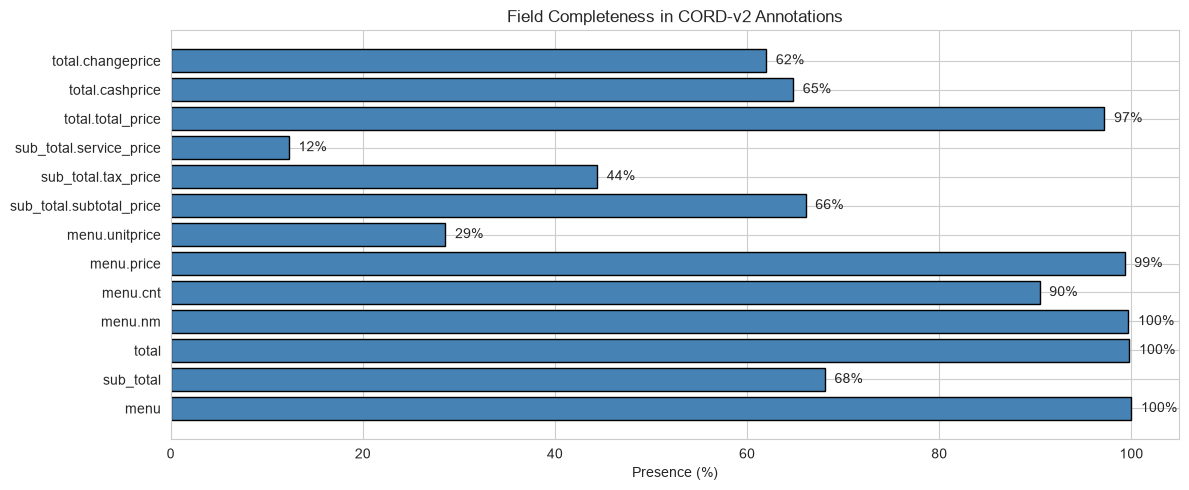

In [6]:
# Field completeness bar chart
fields = list(field_presence.keys())
percentages = []
for f in fields:
    if f.startswith("menu."):
        percentages.append(100 * field_presence[f] / n_items_total)
    else:
        percentages.append(100 * field_presence[f] / n_total)

plt.figure(figsize=(12, 5))
bars = plt.barh(fields, percentages, color="steelblue", edgecolor="black")
plt.xlabel("Presence (%)")
plt.title("Field Completeness in CORD-v2 Annotations")
plt.xlim(0, 105)
for bar, pct in zip(bars, percentages):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f"{pct:.0f}%", va="center")
plt.tight_layout()
plt.savefig("../results/figures/field_completeness.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Items per Receipt Distribution

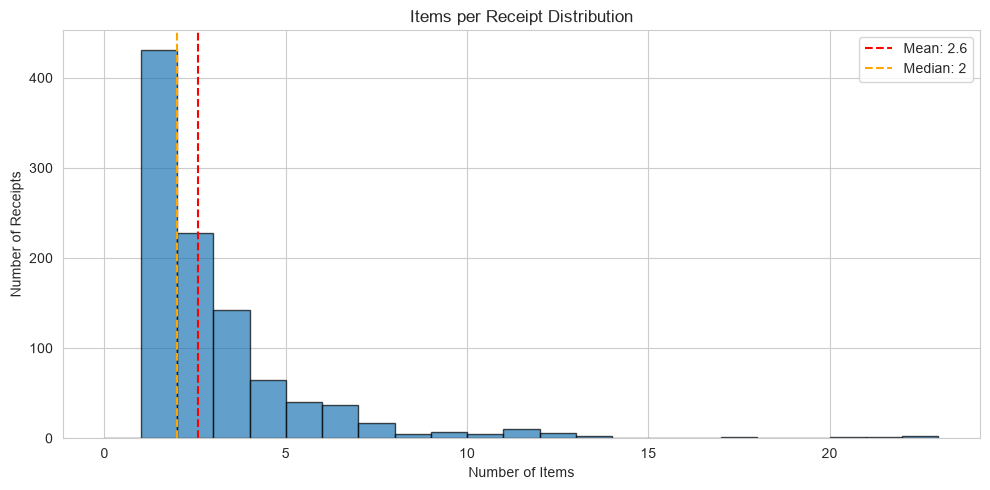

Items per receipt — min: 1, max: 22, mean: 2.6, median: 2


In [7]:
plt.figure(figsize=(10, 5))
plt.hist(items_per_receipt, bins=range(0, max(items_per_receipt) + 2), edgecolor="black", alpha=0.7)
plt.xlabel("Number of Items")
plt.ylabel("Number of Receipts")
plt.title("Items per Receipt Distribution")
plt.axvline(np.mean(items_per_receipt), color="red", linestyle="--", label=f"Mean: {np.mean(items_per_receipt):.1f}")
plt.axvline(np.median(items_per_receipt), color="orange", linestyle="--", label=f"Median: {np.median(items_per_receipt):.0f}")
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/items_per_receipt.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Items per receipt — min: {min(items_per_receipt)}, max: {max(items_per_receipt)}, "
      f"mean: {np.mean(items_per_receipt):.1f}, median: {np.median(items_per_receipt):.0f}")

## 5. Sample Images Visualization

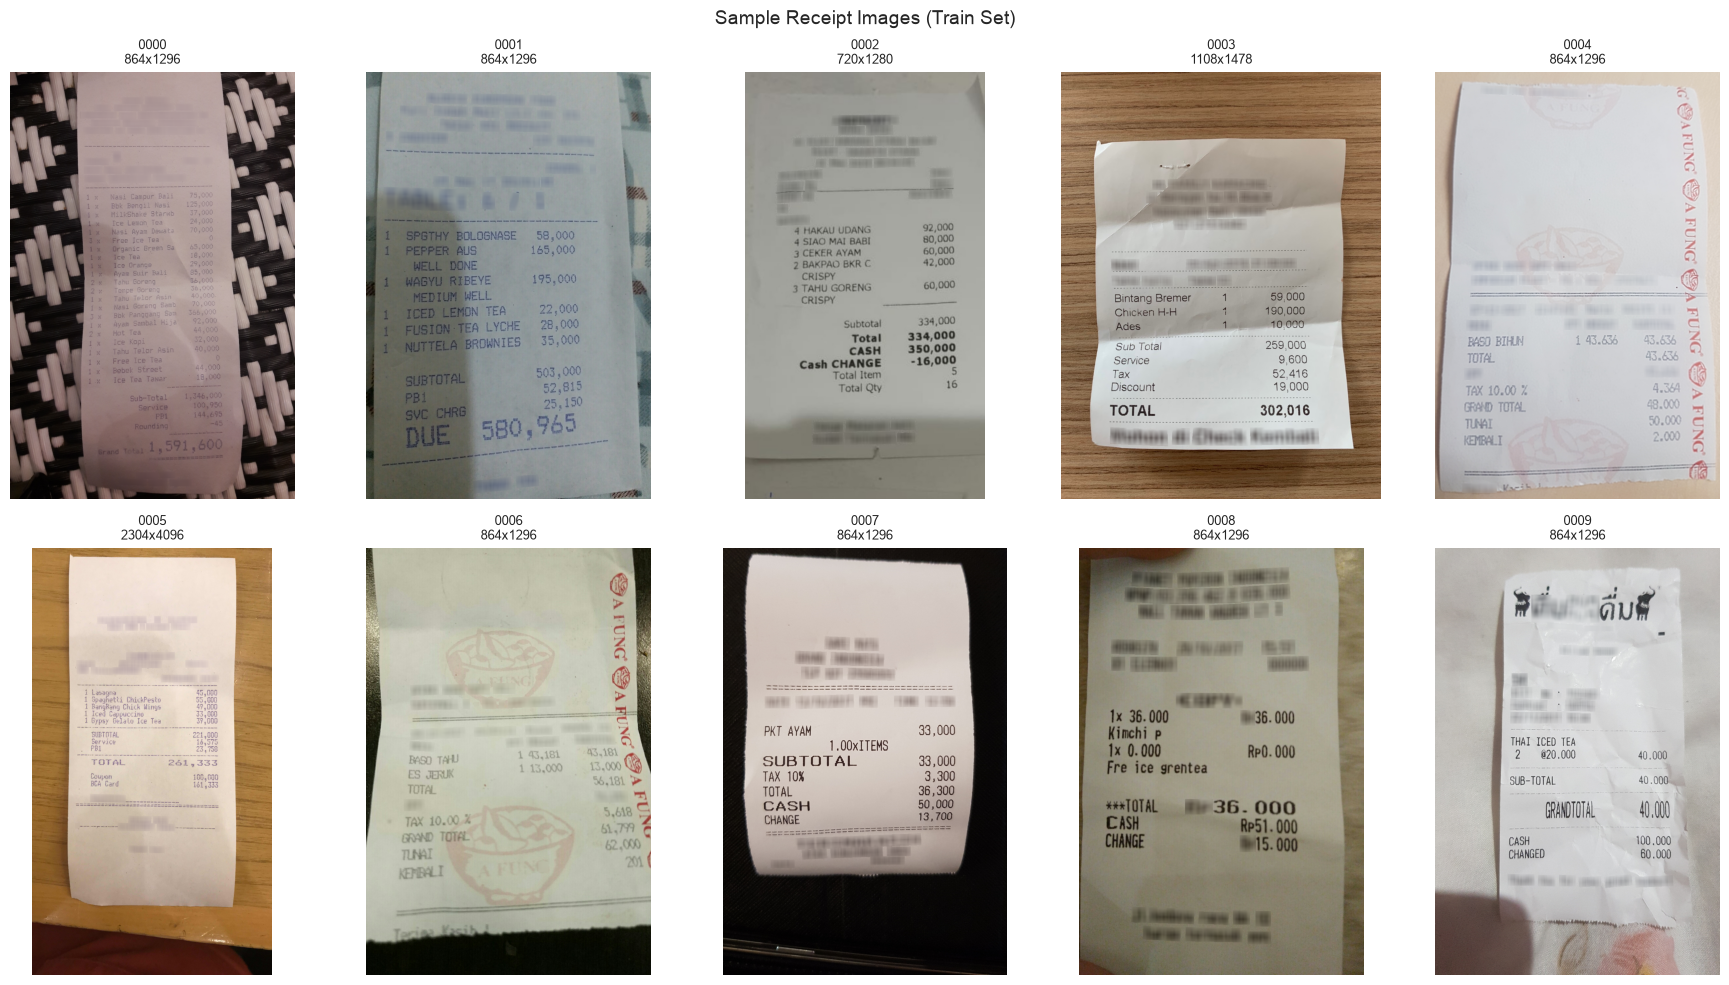

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(18, 10))

img_dir = DATA_DIR / "train" / "images"
img_files = sorted(img_dir.glob("*.png"))[:10]

for ax, img_path in zip(axes.flat, img_files):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"{img_path.stem}\n{img.size[0]}x{img.size[1]}", fontsize=9)
    ax.axis("off")

plt.suptitle("Sample Receipt Images (Train Set)", fontsize=14)
plt.tight_layout()
plt.savefig("../results/figures/sample_images.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Annotation Example

In [9]:
# Show a full annotation example
with open(DATA_DIR / "train" / "annotations" / "0000.json") as f:
    sample = json.load(f)

print("gt_parse structure:")
print(json.dumps(sample["gt_parse"], indent=2)[:2000])

gt_parse structure:
{
  "menu": [
    {
      "nm": "Nasi Campur Bali",
      "cnt": "1 x",
      "price": "75,000"
    },
    {
      "nm": "Bbk Bengil Nasi",
      "cnt": "1 x",
      "price": "125,000"
    },
    {
      "nm": "MilkShake Starwb",
      "cnt": "1 x",
      "price": "37,000"
    },
    {
      "nm": "Ice Lemon Tea",
      "cnt": "1 x",
      "price": "24,000"
    },
    {
      "nm": "Nasi Ayam Dewata",
      "cnt": "1 x",
      "price": "70,000"
    },
    {
      "nm": "Free Ice Tea",
      "cnt": "3 x",
      "price": "0"
    },
    {
      "nm": "Organic Green Sa",
      "cnt": "1 x",
      "price": "65,000"
    },
    {
      "nm": "Ice Tea",
      "cnt": "1 x",
      "price": "18,000"
    },
    {
      "nm": "Ice Orange",
      "cnt": "1 x",
      "price": "29,000"
    },
    {
      "nm": "Ayam Suir Bali",
      "cnt": "1 x",
      "price": "85,000"
    },
    {
      "nm": "Tahu Goreng",
      "cnt": "2 x",
      "price": "36,000"
    },
    {
      "nm": "Te

## 7. Summary Statistics

In [10]:
print("=" * 50)
print("CORD-v2 Dataset Summary")
print("=" * 50)
print(f"Total images: {sum(c['images'] for c in splits.values())}")
print(f"  Train: {splits['train']['images']}")
print(f"  Validation: {splits['validation']['images']}")
print(f"  Test: {splits['test']['images']}")
print(f"\nImage dimensions:")
print(f"  Width range: {min(widths)}–{max(widths)} px (mean: {np.mean(widths):.0f})")
print(f"  Height range: {min(heights)}–{max(heights)} px (mean: {np.mean(heights):.0f})")
print(f"\nAnnotations:")
print(f"  Items per receipt: {np.mean(items_per_receipt):.1f} avg (max: {max(items_per_receipt)})")
print(f"  Total field present: {100*field_presence['total']/n_total:.0f}% of receipts")
print(f"  Sub_total present: {100*field_presence['sub_total']/n_total:.0f}% of receipts")
print(f"  Schema coverage: 97.7% (Pydantic validation)")

CORD-v2 Dataset Summary
Total images: 1000
  Train: 800
  Validation: 100
  Test: 100

Image dimensions:
  Width range: 204–3024 px (mean: 999)
  Height range: 336–4224 px (mean: 1575)

Annotations:
  Items per receipt: 2.6 avg (max: 22)
  Total field present: 100% of receipts
  Sub_total present: 68% of receipts
  Schema coverage: 97.7% (Pydantic validation)
